# Data Loading and Processing

Step 1: Import libraries

In [ ]:
import pandas as pd
import numpy as np

Step 2: Mount google drive, read the csv file

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
df = pd.read_csv("/content/drive/MyDrive/kidney_disease (2).csv")

Step 3: Understanding the dataset

In [ ]:
df.head()

,id,age,bp,sg,al,su,rbc,pc,pcc,ba,...,pcv,wc,rc,htn,dm,cad,appet,pe,ane,classification
0,0,48.0,80.0,1.020,1.0,0.0,NaN,normal,notpresent,notpresent,...,44,7800,5.2,yes,yes,no,good,no,no,ckd
1,1,7.0,50.0,1.020,4.0,0.0,NaN,normal,notpresent,notpresent,...,38,6000,NaN,no,no,no,good,no,no,ckd
2,2,62.0,80.0,1.010,2.0,3.0,normal,normal,notpresent,notpresent,...,31,7500,NaN,no,yes,no,poor,no,yes,ckd
3,3,48.0,70.0,1.005,4.0,0.0,normal,abnormal,present,notpresent,...,32,6700,3.9,yes,no,no,poor,yes,yes,ckd
4,4,51.0,80.0,1.010,2.0,0.0,normal,normal,notpresent,notpresent,...,35,7300,4.6,no,no,no,good,no,no,ckd


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 26 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   id              400 non-null    int64  
 1   age             391 non-null    float64
 2   bp              388 non-null    float64
 3   sg              353 non-null    float64
 4   al              354 non-null    float64
 5   su              351 non-null    float64
 6   rbc             248 non-null    object 
 7   pc              335 non-null    object 
 8   pcc             396 non-null    object 
 9   ba              396 non-null    object 
 10  bgr             356 non-null    float64
 11  bu              381 non-null    float64
 12  sc              383 non-null    float64
 13  sod             313 non-null    float64
 14  pot             312 non-null    float64
 15  hemo            348 non-null    float64
 16  pcv             330 non-null    object 
 17  wc              295 non-null    obj

In [ ]:
#drop the 'id' column because it is not needed
df.drop('id', axis = 1, inplace = True)
df.columns = ['age', 'blood_pressure', 'specific_gravity', 'albumin', 'sugar', 'red_blood_cells', 'pus_cell',
              'pus_cell_clumps', 'bacteria', 'blood_glucose_random', 'blood_urea', 'serum_creatinine', 'sodium',
              'potassium', 'haemoglobin', 'packed_cell_volume', 'white_blood_cell_count', 'red_blood_cell_count',
              'hypertension', 'diabetes_mellitus', 'coronary_artery_disease', 'appetite', 'peda_edema',
              'anemia', 'class']

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 25 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   age                      391 non-null    float64
 1   blood_pressure           388 non-null    float64
 2   specific_gravity         353 non-null    float64
 3   albumin                  354 non-null    float64
 4   sugar                    351 non-null    float64
 5   red_blood_cells          248 non-null    object 
 6   pus_cell                 335 non-null    object 
 7   pus_cell_clumps          396 non-null    object 
 8   bacteria                 396 non-null    object 
 9   blood_glucose_random     356 non-null    float64
 10  blood_urea               381 non-null    float64
 11  serum_creatinine         383 non-null    float64
 12  sodium                   313 non-null    float64
 13  potassium                312 non-null    float64
 14  haemoglobin              3

Step 4 : Check for null values

In [ ]:
print(df.isnull().sum())

age                          9
blood_pressure              12
specific_gravity            47
albumin                     46
sugar                       49
red_blood_cells            152
pus_cell                    65
pus_cell_clumps              4
bacteria                     4
blood_glucose_random        44
blood_urea                  19
serum_creatinine            17
sodium                      87
potassium                   88
haemoglobin                 52
packed_cell_volume          70
white_blood_cell_count     105
red_blood_cell_count       130
hypertension                 2
diabetes_mellitus            2
coronary_artery_disease      2
appetite                     1
peda_edema                   1
anemia                       1
class                        0
dtype: int64


Step 5: Handle missing values

In [ ]:
#The columns : 'red_blood_cells' and 'red_blood_cell_count', 'white_blood_cell_count' have too many missing values (>30%). Hence, dropping the columns.
df.drop(columns=['red_blood_cells','white_blood_cell_count','red_blood_cell_count'], inplace=True)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 22 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   age                      391 non-null    float64
 1   blood_pressure           388 non-null    float64
 2   specific_gravity         353 non-null    float64
 3   albumin                  354 non-null    float64
 4   sugar                    351 non-null    float64
 5   pus_cell                 335 non-null    object 
 6   pus_cell_clumps          396 non-null    object 
 7   bacteria                 396 non-null    object 
 8   blood_glucose_random     356 non-null    float64
 9   blood_urea               381 non-null    float64
 10  serum_creatinine         383 non-null    float64
 11  sodium                   313 non-null    float64
 12  potassium                312 non-null    float64
 13  haemoglobin              348 non-null    float64
 14  packed_cell_volume       3

In [ ]:
# Convert the column packed_cell_volume' to numeric
df['packed_cell_volume'] = pd.to_numeric(df['packed_cell_volume'], errors='coerce')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 22 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   age                      391 non-null    float64
 1   blood_pressure           388 non-null    float64
 2   specific_gravity         353 non-null    float64
 3   albumin                  354 non-null    float64
 4   sugar                    351 non-null    float64
 5   pus_cell                 335 non-null    object 
 6   pus_cell_clumps          396 non-null    object 
 7   bacteria                 396 non-null    object 
 8   blood_glucose_random     356 non-null    float64
 9   blood_urea               381 non-null    float64
 10  serum_creatinine         383 non-null    float64
 11  sodium                   313 non-null    float64
 12  potassium                312 non-null    float64
 13  haemoglobin              348 non-null    float64
 14  packed_cell_volume       3

In [ ]:
# Fill missing values in numerical columns with the mean of each column
num_cols = df.select_dtypes(include=['float64']).columns
df[num_cols] = df[num_cols].fillna(df[num_cols].mean())

In [ ]:
# Fill missing values with the mode (most frequent value) of the column
cat_cols = df.select_dtypes(include='object').columns
for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

In [ ]:
df.isnull().sum()

,0
age,0
blood_pressure,0
specific_gravity,0
albumin,0
sugar,0
pus_cell,0
pus_cell_clumps,0
bacteria,0
blood_glucose_random,0
blood_urea,0


Step 6 : Encode categorical data (0, 1)

In [ ]:
# Iterate through each categorical column and print its unique values
for col in cat_cols:
    print(f"{col} : {df[col].unique()}\n")

pus_cell : ['normal' 'abnormal']

pus_cell_clumps : ['notpresent' 'present']

bacteria : ['notpresent' 'present']

hypertension : ['yes' 'no']

diabetes_mellitus : ['yes' 'no' ' yes' '\tno' '\tyes']

coronary_artery_disease : ['no' 'yes' '\tno']

appetite : ['good' 'poor']

peda_edema : ['no' 'yes']

anemia : ['no' 'yes']

class : ['ckd' 'ckd\t' 'notckd']



In [ ]:
# Strip extra spaces or tabs from object columns
for col in df.select_dtypes(include='object').columns:
    df[col] = df[col].str.strip()


In [ ]:
for col in cat_cols:
    print(f"{col} : {df[col].unique()}\n")

pus_cell : ['normal' 'abnormal']

pus_cell_clumps : ['notpresent' 'present']

bacteria : ['notpresent' 'present']

hypertension : ['yes' 'no']

diabetes_mellitus : ['yes' 'no']

coronary_artery_disease : ['no' 'yes']

appetite : ['good' 'poor']

peda_edema : ['no' 'yes']

anemia : ['no' 'yes']

class : ['ckd' 'notckd']



In [ ]:
# Define a dictionary to store mappings for label encoding
label_mappings = {
    'pus_cell': {'normal': 0, 'abnormal': 1},
    'pus_cell_clumps': {'notpresent': 0, 'present': 1},
    'bacteria': {'notpresent': 0, 'present': 1},
    'hypertension': {'no': 0, 'yes': 1},
    'diabetes_mellitus': {'no': 0, 'yes': 1},
    'coronary_artery_disease': {'no': 0, 'yes': 1},
    'appetite': {'good': 0, 'poor': 1},
    'peda_edema': {'no': 0, 'yes': 1},
    'anemia': {'no': 0, 'yes': 1},
    'class': {'notckd': 0, 'ckd': 1}
}
#apply label encoding
for col, mapping in label_mappings.items():
    df[col] = df[col].map(mapping)


In [ ]:
df

,age,blood_pressure,specific_gravity,albumin,sugar,pus_cell,pus_cell_clumps,bacteria,blood_glucose_random,blood_urea,...,potassium,haemoglobin,packed_cell_volume,hypertension,diabetes_mellitus,coronary_artery_disease,appetite,peda_edema,anemia,class
0,48.0,80.0,1.020,1.0,0.0,0,0,0,121.000000,36.0,...,4.627244,15.4,44.0,1,1,0,0,0,0,1
1,7.0,50.0,1.020,4.0,0.0,0,0,0,148.036517,18.0,...,4.627244,11.3,38.0,0,0,0,0,0,0,1
2,62.0,80.0,1.010,2.0,3.0,0,0,0,423.000000,53.0,...,4.627244,9.6,31.0,0,1,0,1,0,1,1
3,48.0,70.0,1.005,4.0,0.0,1,1,0,117.000000,56.0,...,2.500000,11.2,32.0,1,0,0,1,1,1,1
4,51.0,80.0,1.010,2.0,0.0,0,0,0,106.000000,26.0,...,4.627244,11.6,35.0,0,0,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
395,55.0,80.0,1.020,0.0,0.0,0,0,0,140.000000,49.0,...,4.900000,15.7,47.0,0,0,0,0,0,0,0
396,42.0,70.0,1.025,0.0,0.0,0,0,0,75.000000,31.0,...,3.500000,16.5,54.0,0,0,0,0,0,0,0
397,12.0,80.0,1.020,0.0,0.0,0,0,0,100.000000,26.0,...,4.400000,15.8,49.0,0,0,0,0,0,0,0
398,17.0,60.0,1.025,0.0,0.0,0,0,0,114.000000,50.0,...,4.900000,14.2,51.0,0,0,0,0,0,0,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 22 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   age                      400 non-null    float64
 1   blood_pressure           400 non-null    float64
 2   specific_gravity         400 non-null    float64
 3   albumin                  400 non-null    float64
 4   sugar                    400 non-null    float64
 5   pus_cell                 400 non-null    int64  
 6   pus_cell_clumps          400 non-null    int64  
 7   bacteria                 400 non-null    int64  
 8   blood_glucose_random     400 non-null    float64
 9   blood_urea               400 non-null    float64
 10  serum_creatinine         400 non-null    float64
 11  sodium                   400 non-null    float64
 12  potassium                400 non-null    float64
 13  haemoglobin              400 non-null    float64
 14  packed_cell_volume       4

# Data Visualization

Step 7 : Visualize distributions using histograms

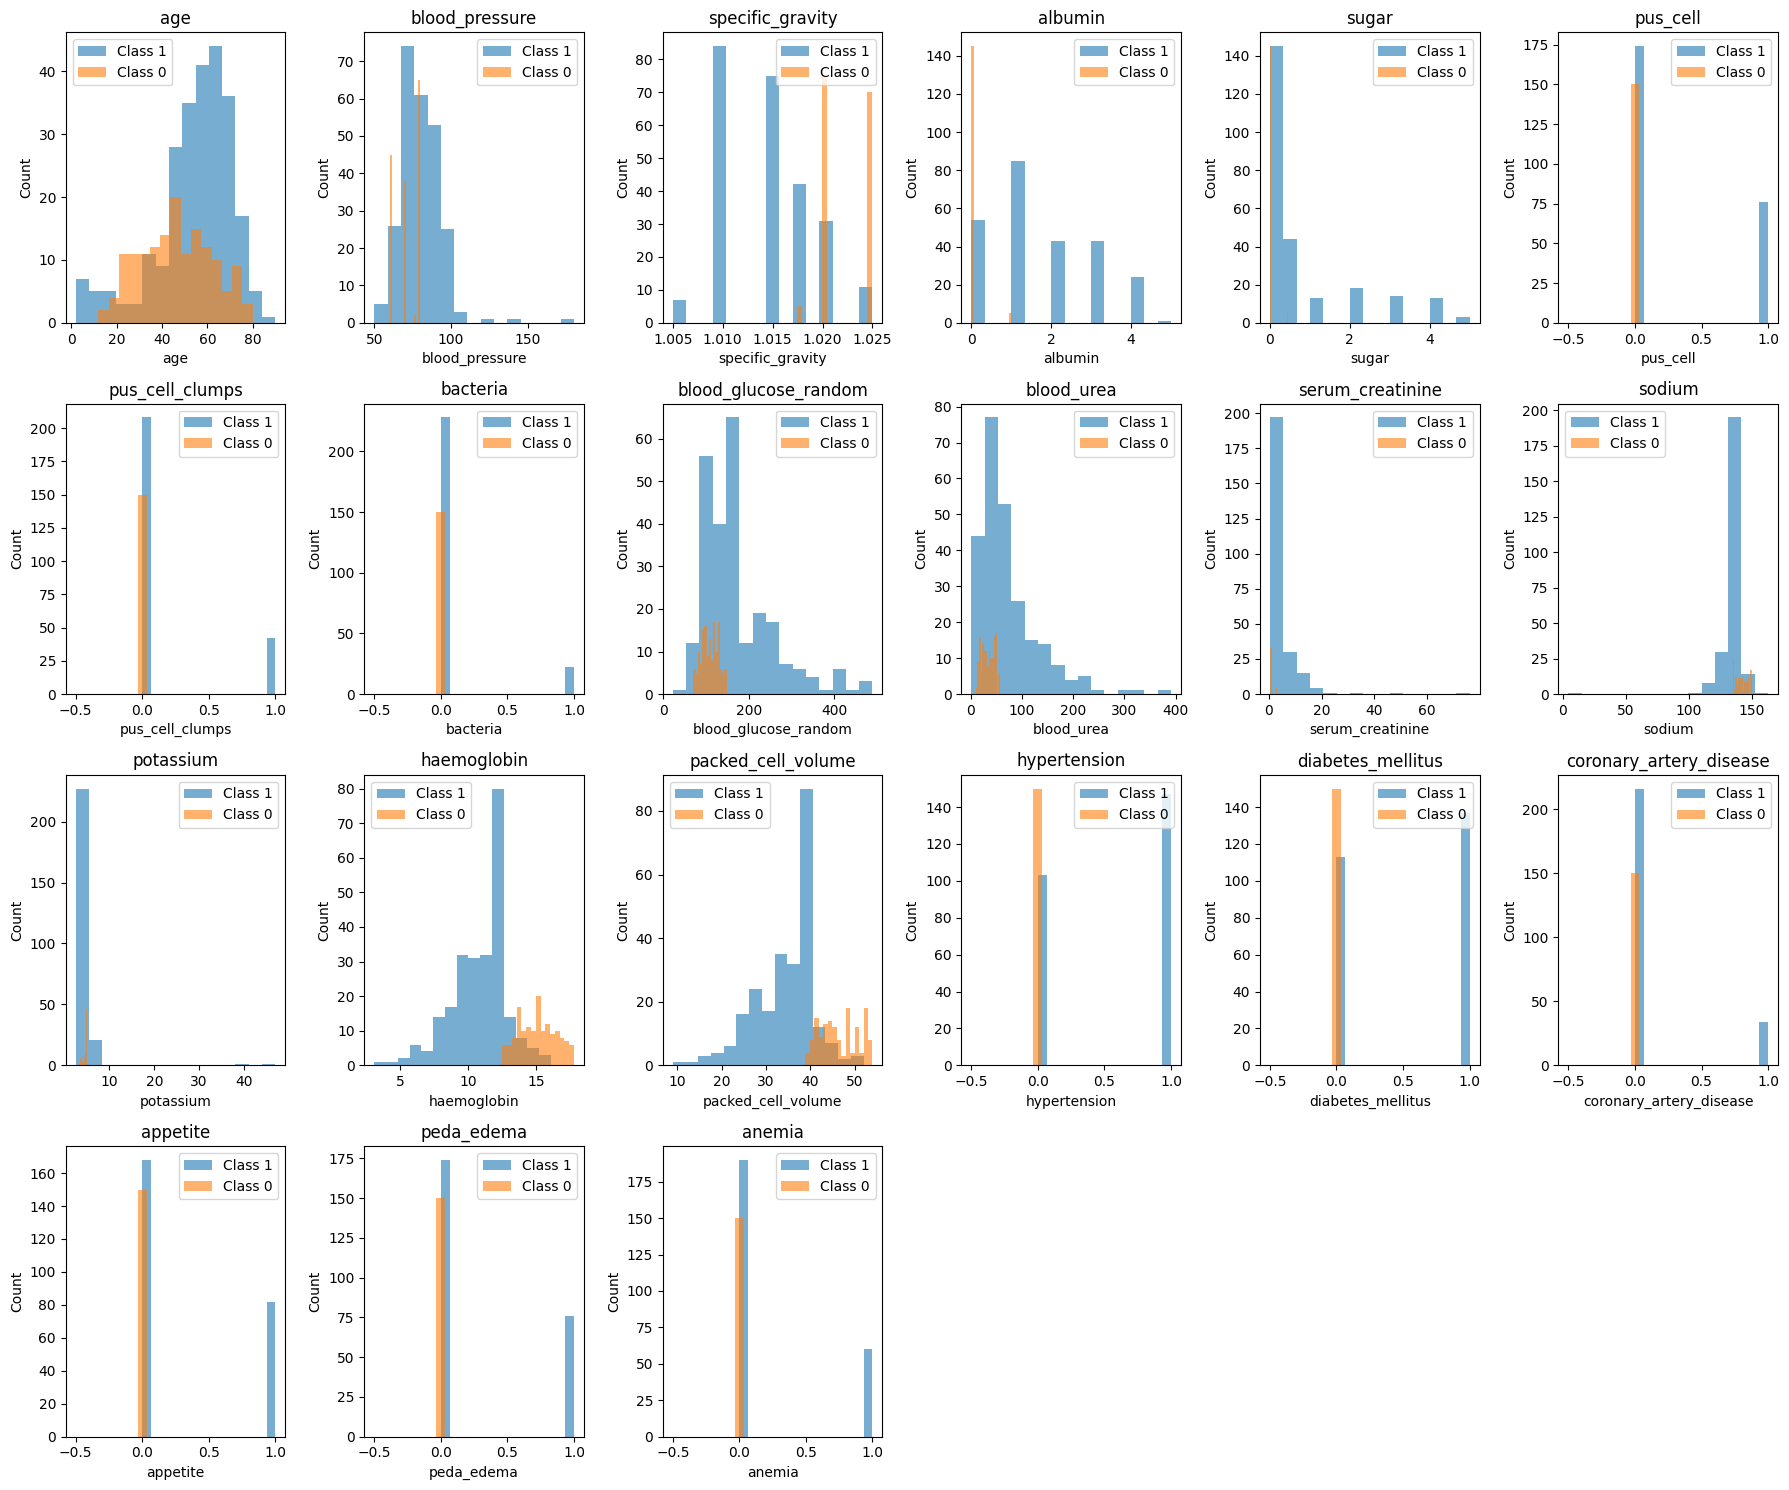

In [ ]:
import matplotlib.pyplot as plt

# Drop 'class' (target) since it's not a feature
features = df.columns.drop('class')

# Set up grid layout: 6 rows x 4 columns (22 plots)
rows = 4
cols = 6
plt.figure(figsize=(18, 15))

for i, feature in enumerate(features):
    plt.subplot(rows, cols, i + 1)

    for label in df['class'].unique():
        subset = df[df['class'] == label]
        plt.hist(subset[feature], bins=15, alpha=0.6, label=f'Class {label}')

    plt.title(feature)
    plt.xlabel(feature)
    plt.ylabel('Count')
    plt.legend()

plt.tight_layout()
plt.show()


In [ ]:
# Example: Clip extreme values to handle outliers
df['blood_urea'] = df['blood_urea'].clip(lower=0, upper=150)
df['serum_creatinine'] = df['serum_creatinine'].clip(lower=0, upper=10)

Step 8: Calculate and visualize the correlation matrix

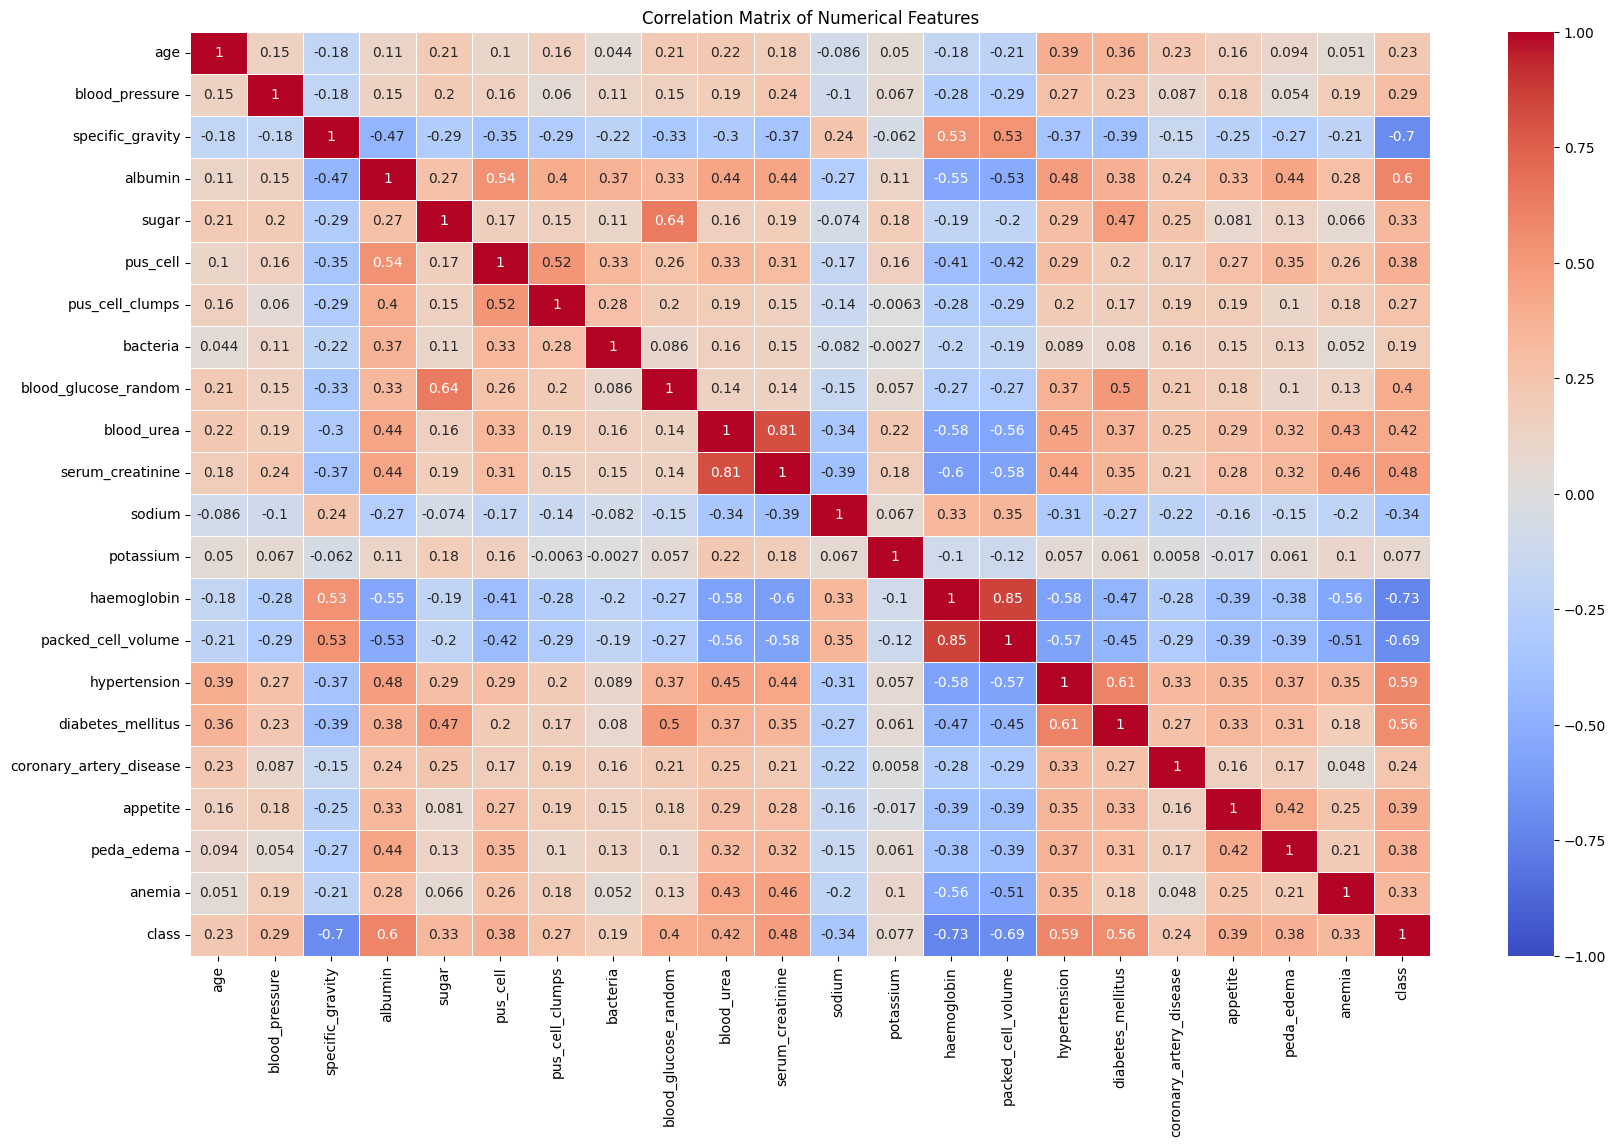

Highly Correlated Numerical Features (>0.7): [('blood_urea', 'serum_creatinine'), ('haemoglobin', 'packed_cell_volume'), ('haemoglobin', 'class')]


In [ ]:
# Correlation matrix for numerical features
import seaborn as sns
numerical_features = df.select_dtypes(include=['float64','int64']).columns
corr_matrix = df[numerical_features].corr()

# Plot the correlation heatmap
plt.figure(figsize=(20, 12))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", vmin=-1, vmax=1, linewidths=0.5)
plt.title("Correlation Matrix of Numerical Features")
plt.show()

# Identify highly correlated features
high_corr = np.where(np.abs(corr_matrix) > 0.7)
high_corr_features = [(numerical_features[i], numerical_features[j]) for i, j in zip(*high_corr) if i != j and i < j]
print("Highly Correlated Numerical Features (>0.7):", high_corr_features)

Step 9 : Plot a barplot showing correlation of features withh target class

/tmp/ipython-input-1742082539.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=correlation_with_class.values, y=correlation_with_class.index, palette='coolwarm')


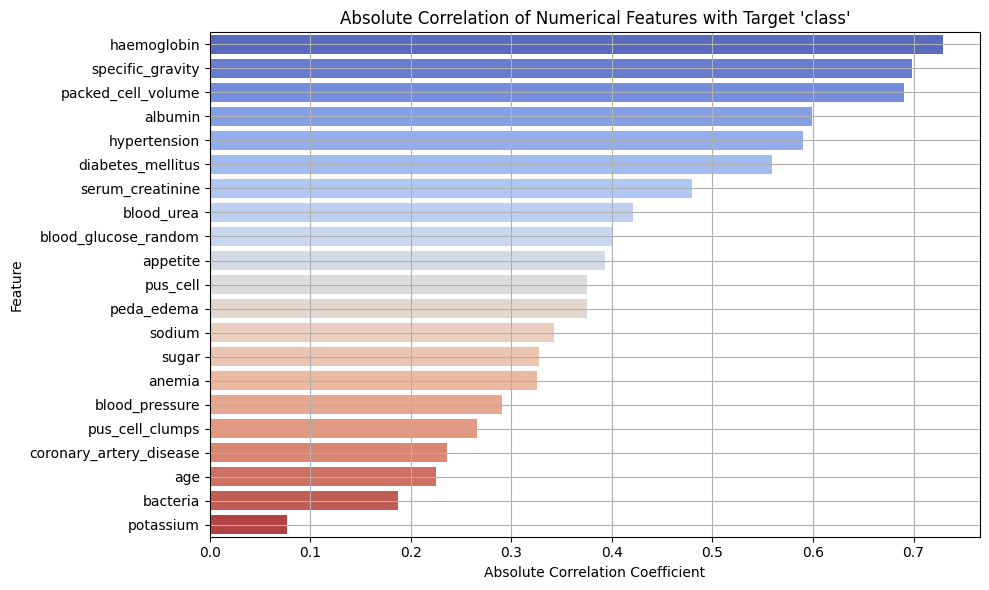

In [ ]:
# Select only numeric columns
numerical_features = df.select_dtypes(include=['float64', 'int64']).columns

# Compute absolute correlation with 'class' (excluding 'class' itself)
correlation_with_class = df[numerical_features].corr()['class'].drop('class').abs()

# Sort by absolute correlation value
correlation_with_class = correlation_with_class.sort_values(ascending=False)

# Plot the barplot
plt.figure(figsize=(10, 6))
sns.barplot(x=correlation_with_class.values, y=correlation_with_class.index, palette='coolwarm')
plt.title("Absolute Correlation of Numerical Features with Target 'class'")
plt.xlabel("Absolute Correlation Coefficient")
plt.ylabel("Feature")
plt.grid(True)
plt.tight_layout()
plt.show()


# Feature Selection

Step 10 : Drop the features with high correlation withh other feature, low correlation with class

In [ ]:
df = df.drop('packed_cell_volume', axis=1)

df = df.drop('potassium', axis=1)

df = df.drop('bacteria', axis=1)

df = df.drop('age', axis=1)

print(df.columns)



Index(['blood_pressure', 'specific_gravity', 'albumin', 'sugar', 'pus_cell',
       'pus_cell_clumps', 'blood_glucose_random', 'blood_urea',
       'serum_creatinine', 'sodium', 'haemoglobin', 'hypertension',
       'diabetes_mellitus', 'coronary_artery_disease', 'appetite',
       'peda_edema', 'anemia', 'class'],
      dtype='object')


Step 11:  Select Top 10 features using SelectKBest

In [ ]:
from sklearn.feature_selection import SelectKBest, f_classif

# Split into X (features) and y (target)
X = df.drop('class', axis=1)
y = df['class']

# Apply SelectKBest to choose top k features (e.g., top 10)
k = 10
selector = SelectKBest(score_func=f_classif, k=k)
X_new = selector.fit_transform(X, y)

# Get the names of the selected features as a list
selected_features = list(X.columns[selector.get_support()])
print(f"Top {k} selected features:", selected_features)


Top 10 selected features: ['specific_gravity', 'albumin', 'blood_glucose_random', 'blood_urea', 'serum_creatinine', 'haemoglobin', 'hypertension', 'diabetes_mellitus', 'appetite', 'peda_edema']


Step 11: Plot the selected features to visualize patterns

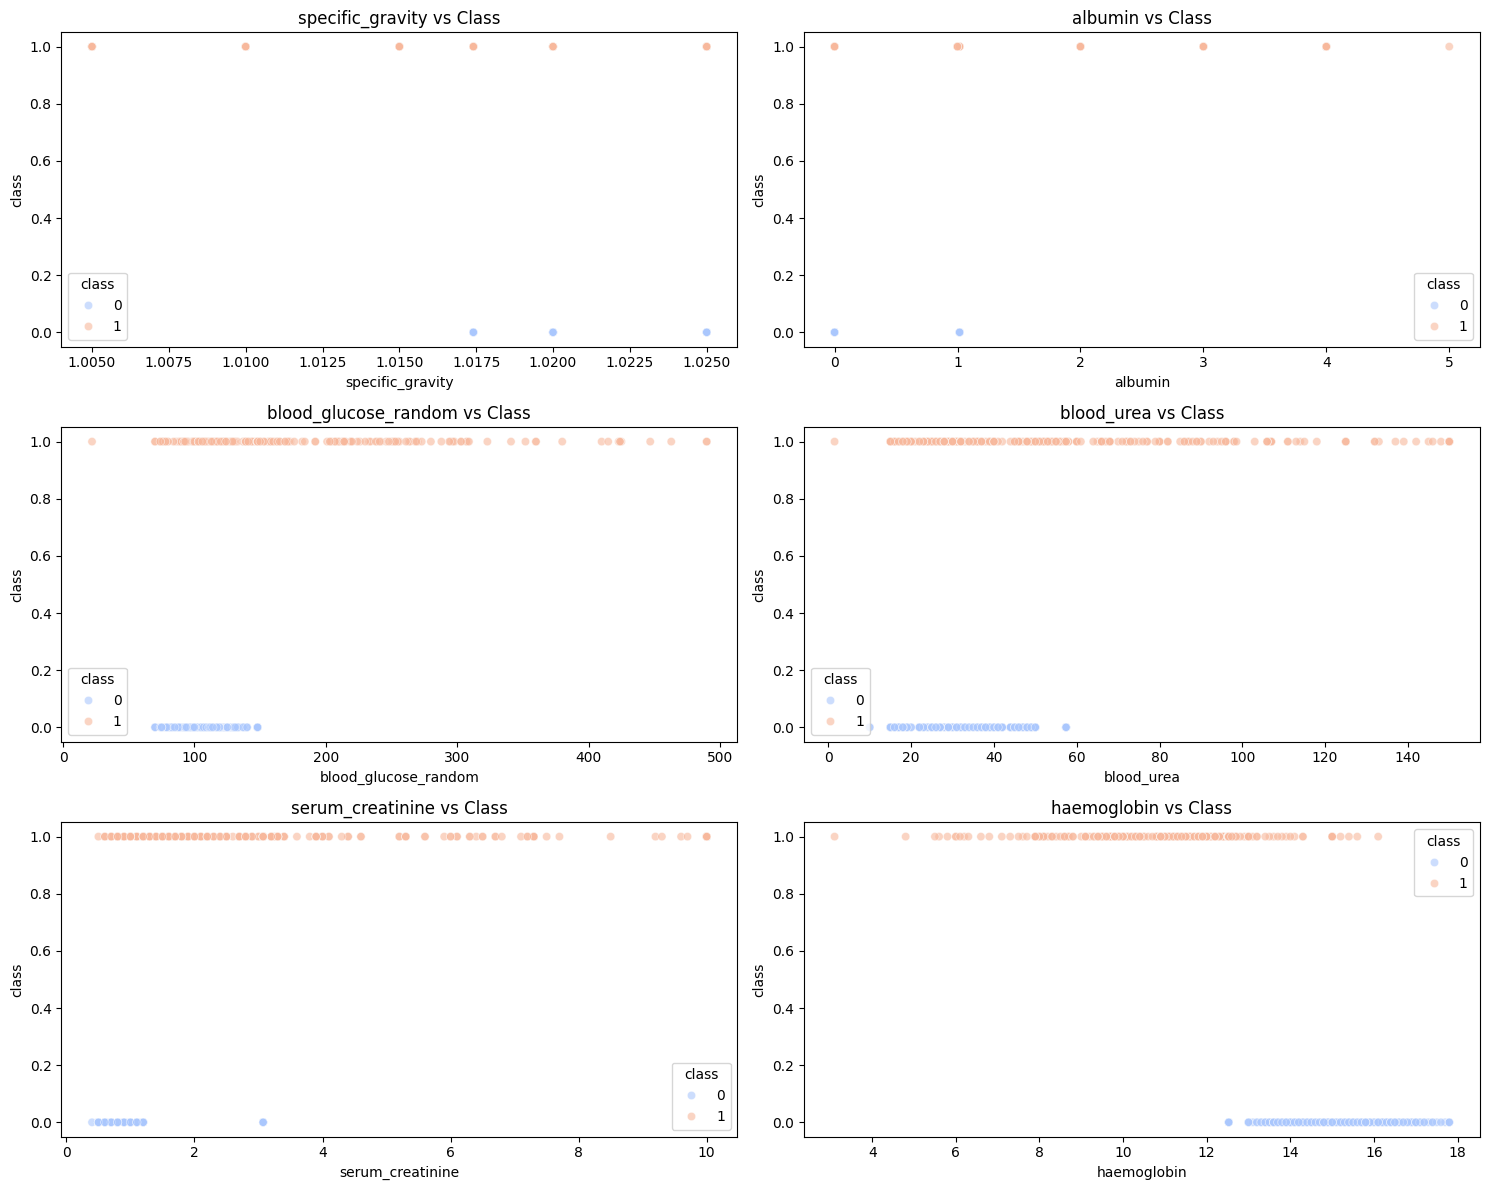

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# List of numeric and binary features
numeric_features = ['specific_gravity', 'albumin', 'blood_glucose_random', 'blood_urea', 'serum_creatinine', 'haemoglobin']

# Scatter plots for numeric features
plt.figure(figsize=(15, 12))
for i, feature in enumerate(numeric_features):
    plt.subplot(3, 2, i + 1)
    sns.scatterplot(data=df, x=feature, y='class', alpha=0.6, hue='class', palette='coolwarm')
    plt.title(f'{feature} vs Class')
plt.tight_layout()
plt.show()


In [ ]:
# Now select the features and include the 'class' column
df = df[selected_features + ['class']]

print(df)


     specific_gravity  albumin  blood_glucose_random  blood_urea  \
0               1.020      1.0            121.000000        36.0   
1               1.020      4.0            148.036517        18.0   
2               1.010      2.0            423.000000        53.0   
3               1.005      4.0            117.000000        56.0   
4               1.010      2.0            106.000000        26.0   
..                ...      ...                   ...         ...   
395             1.020      0.0            140.000000        49.0   
396             1.025      0.0             75.000000        31.0   
397             1.020      0.0            100.000000        26.0   
398             1.025      0.0            114.000000        50.0   
399             1.025      0.0            131.000000        18.0   

     serum_creatinine  haemoglobin  hypertension  diabetes_mellitus  appetite  \
0                 1.2         15.4             1                  1         0   
1                 0.8

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   specific_gravity      400 non-null    float64
 1   albumin               400 non-null    float64
 2   blood_glucose_random  400 non-null    float64
 3   blood_urea            400 non-null    float64
 4   serum_creatinine      400 non-null    float64
 5   haemoglobin           400 non-null    float64
 6   hypertension          400 non-null    int64  
 7   diabetes_mellitus     400 non-null    int64  
 8   appetite              400 non-null    int64  
 9   peda_edema            400 non-null    int64  
 10  class                 400 non-null    int64  
dtypes: float64(6), int64(5)
memory usage: 34.5 KB


# Model Training and Evaluation

Step 12: Split the data in to training (70%) and testing (30%)

In [ ]:
from sklearn.model_selection import train_test_split

X = df.drop('class', axis=1)
y = df['class']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, stratify=y, random_state=1)


Step 13: Scale features using standard scaler

In [ ]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

Step 13: Train the Logistic Regression Model and evaluate it

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

np.random.seed(42)  # for reproducibility
X_train_scaled_ = X_train_scaled + np.random.normal(0, 0.5, X_train_scaled.shape)
X_test_scaled_ = X_test_scaled + np.random.normal(0, 0.5, X_test_scaled.shape)

model = LogisticRegression()
model.fit(X_train_scaled_, y_train)
y_pred = model.predict(X_test_scaled_)

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))
print("Accuracy:", accuracy_score(y_test, y_pred))


[[44  1]
 [ 2 73]]
              precision    recall  f1-score   support

           0       0.96      0.98      0.97        45
           1       0.99      0.97      0.98        75

    accuracy                           0.97       120
   macro avg       0.97      0.98      0.97       120
weighted avg       0.98      0.97      0.98       120

Accuracy: 0.975


Step 14 : Train the Naive Bayes model and evaluate

In [ ]:
from sklearn.naive_bayes import GaussianNB


nb_model = GaussianNB()
nb_model.fit(X_train_scaled, y_train)

y_pred_nb = nb_model.predict(X_test_scaled)


print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_nb))
print("\nClassification Report:\n", classification_report(y_test, y_pred_nb))
print("Accuracy:", accuracy_score(y_test, y_pred_nb))


Confusion Matrix:
 [[45  0]
 [ 4 71]]

Classification Report:
               precision    recall  f1-score   support

           0       0.92      1.00      0.96        45
           1       1.00      0.95      0.97        75

    accuracy                           0.97       120
   macro avg       0.96      0.97      0.97       120
weighted avg       0.97      0.97      0.97       120

Accuracy: 0.9666666666666667


Step 15 : Train the Decision Tree model and evaluate

In [ ]:
from sklearn.tree import DecisionTreeClassifier

dtree = DecisionTreeClassifier(criterion='entropy', max_depth=4, random_state=1)
dtree.fit(X_train_scaled, y_train)

DecisionTreeClassifier(criterion='entropy', max_depth=4, random_state=1)

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

y_pred_dt = dtree.predict(X_test_scaled)

print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_dt))
print("\nClassification Report:\n", classification_report(y_test, y_pred_dt))
print("Accuracy Score:", accuracy_score(y_test, y_pred_dt))


Confusion Matrix:
 [[45  0]
 [ 2 73]]

Classification Report:
               precision    recall  f1-score   support

           0       0.96      1.00      0.98        45
           1       1.00      0.97      0.99        75

    accuracy                           0.98       120
   macro avg       0.98      0.99      0.98       120
weighted avg       0.98      0.98      0.98       120

Accuracy Score: 0.9833333333333333


Step 15 : Visualize the Decision tree

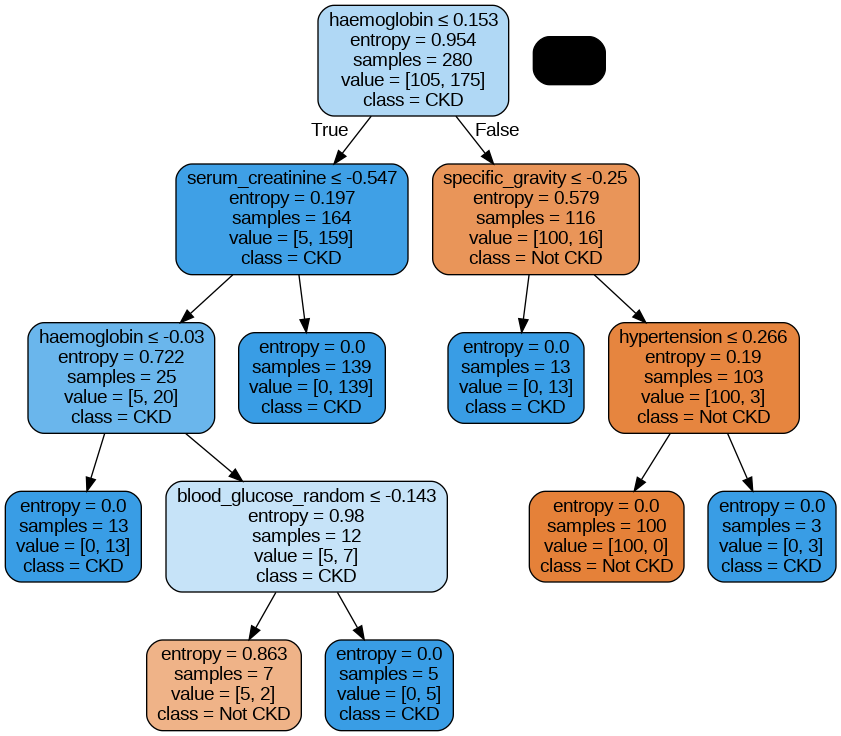

In [ ]:
from sklearn.tree import export_graphviz
import pydotplus
from IPython.display import Image
from io import StringIO

dot_data = StringIO()

export_graphviz(
    dtree,
    out_file=dot_data,
    filled=True,
    rounded=True,
    feature_names=X.columns,
    class_names=['Not CKD', 'CKD'],
    special_characters=True
)

graph = pydotplus.graph_from_dot_data(dot_data.getvalue())
Image(graph.create_png())


In [ ]:
print(df.columns)

Index(['specific_gravity', 'albumin', 'blood_glucose_random', 'blood_urea',
       'serum_creatinine', 'haemoglobin', 'hypertension', 'diabetes_mellitus',
       'appetite', 'peda_edema', 'class'],
      dtype='object')


Step 16 : Compare the results

In [ ]:
results = pd.DataFrame({
    "Model": ["Logistic Regression", "Naive Bayes", "Decision Tree"],
    "Accuracy": [
        accuracy_score(y_test, y_pred),
        accuracy_score(y_test, y_pred_nb),
        accuracy_score(y_test, y_pred_dt)
    ]
})

In [ ]:
results = results.sort_values(by="Accuracy", ascending=False).reset_index(drop=True)

print(results)


                 Model  Accuracy
0        Decision Tree  0.983333
1  Logistic Regression  0.975000
2          Naive Bayes  0.966667


                     Accuracy  Precision  Recall  F1 Score
Logistic Regression     0.975      0.986   0.973     0.980
Naive Bayes             0.967      1.000   0.947     0.973
Decision Tree           0.983      1.000   0.973     0.986


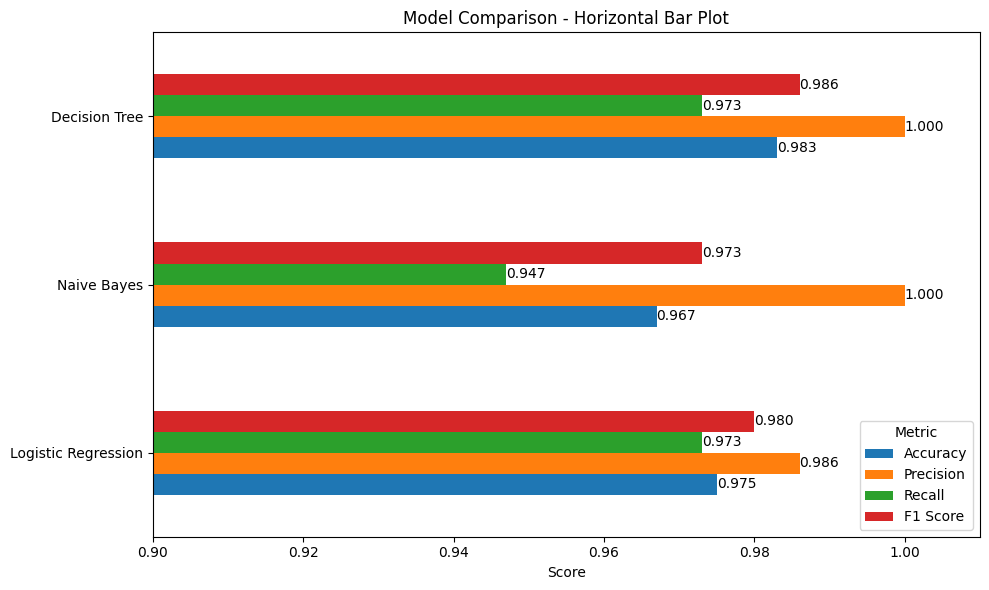

In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score

# Initialize dictionary to store metrics
results = {}

#Logistic Regression
logistic_pred = model.predict(X_test_scaled_)
results['Logistic Regression'] = {
    'Accuracy': accuracy_score(y_test, logistic_pred),
    'Precision': precision_score(y_test, logistic_pred),
    'Recall': recall_score(y_test, logistic_pred),
    'F1 Score': f1_score(y_test, logistic_pred)
}

#Naive Bayes
nb_pred = nb_model.predict(X_test_scaled)
results['Naive Bayes'] = {
    'Accuracy': accuracy_score(y_test, nb_pred),
    'Precision': precision_score(y_test, nb_pred),
    'Recall': recall_score(y_test, nb_pred),
    'F1 Score': f1_score(y_test, nb_pred)
}

#Decision Tree
dt_pred = dtree.predict(X_test_scaled)
results['Decision Tree'] = {
    'Accuracy': accuracy_score(y_test, dt_pred),
    'Precision': precision_score(y_test, dt_pred),
    'Recall': recall_score(y_test, dt_pred),
    'F1 Score': f1_score(y_test, dt_pred)
}


results_df = pd.DataFrame(results).T
results_df = results_df.round(3)
print(results_df)
ax = results_df.plot(kind='barh', figsize=(10, 6))
plt.title("Model Comparison - Horizontal Bar Plot")
plt.xlabel("Score")
plt.xlim(0.9, 1.01)

# Add value labels
for container in ax.containers:
    ax.bar_label(container, fmt='%.3f')

plt.legend(title='Metric')
plt.tight_layout()
plt.show()




In [ ]:
# Accuracy on training data
train_pred = dtree.predict(X_train_scaled)
train_acc = accuracy_score(y_train, train_pred)
print("Training Accuracy:", train_acc)

# Accuracy on test data (already computed)
test_pred = dtree.predict(X_test_scaled)
test_acc = accuracy_score(y_test, test_pred)
print("Test Accuracy:", test_acc)


Training Accuracy: 0.9928571428571429
Test Accuracy: 0.9833333333333333


Conclusion : Decision tree model is the best model for predicting chronic kis=dney disease using this dataset

# **Clustering(Extra):**

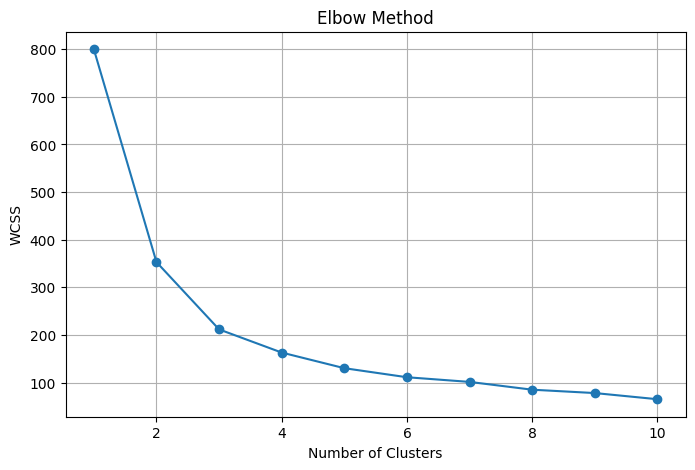

In [ ]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
cluster_df = df[['blood_urea', 'haemoglobin']]
scaler = StandardScaler()
cluster_scaled = scaler.fit_transform(cluster_df)
wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(cluster_scaled)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(range(1, 11), wcss, marker='o')
plt.title('Elbow Method')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.grid()
plt.show()


In [ ]:
kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(cluster_scaled)

df['cluster'] = clusters  # Add cluster labels to original df


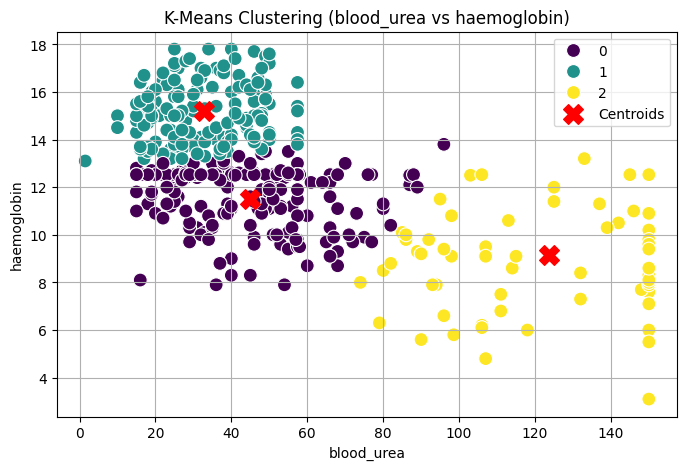

In [ ]:
plt.figure(figsize=(8, 5))
sns.scatterplot(
    x='blood_urea', y='haemoglobin',
    hue='cluster', palette='viridis',
    data=df, s=100
)
centroids = scaler.inverse_transform(kmeans.cluster_centers_)
plt.scatter(centroids[:, 0], centroids[:, 1], s=200, c='red', marker='X', label='Centroids')
plt.title('K-Means Clustering (blood_urea vs haemoglobin)')
plt.legend()
plt.grid()
plt.show()


Through clustering, we observe that individuals with high blood urea tend to have low hemoglobin. Clinically, this is consistent with the fact that kidney dysfunction (indicated by high blood urea) reduces erythropoietin production, leading to low haemoglobin levels. This supports the relevance of clustering in understanding data patterns, even if not directly used for prediction

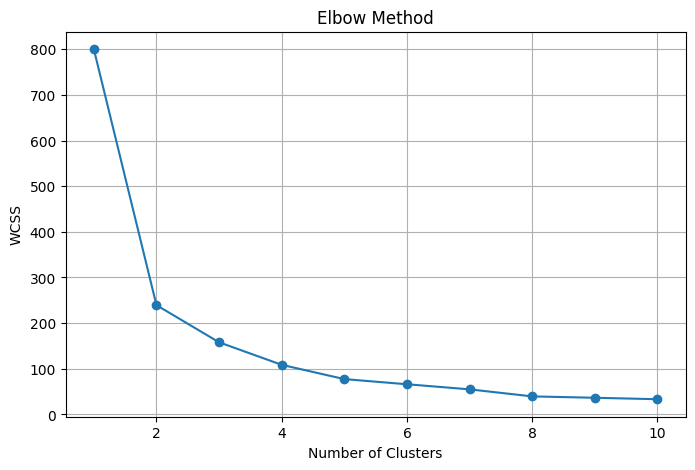

In [ ]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
cluster_df = df[['serum_creatinine', 'blood_urea']]
scaler = StandardScaler()
cluster_scaled = scaler.fit_transform(cluster_df)
wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(cluster_scaled)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(range(1, 11), wcss, marker='o')
plt.title('Elbow Method')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.grid()
plt.show()


In [ ]:
kmeans = KMeans(n_clusters=2, random_state=42)
clusters = kmeans.fit_predict(cluster_scaled)

df['cluster'] = clusters  # Add cluster labels to original df


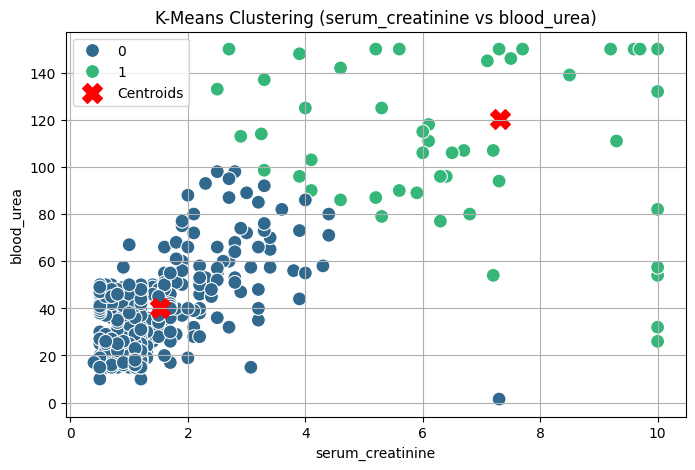

In [ ]:
plt.figure(figsize=(8, 5))
sns.scatterplot(
    x='serum_creatinine', y='blood_urea',
    hue='cluster', palette='viridis',
    data=df, s=100
)
centroids = scaler.inverse_transform(kmeans.cluster_centers_)
plt.scatter(centroids[:, 0], centroids[:, 1], s=200, c='red', marker='X', label='Centroids')
plt.title('K-Means Clustering (serum_creatinine vs blood_urea)')
plt.legend()
plt.grid()
plt.show()


Through clustering, we observe that individuals with high serum creatinine levels tend to also have high blood urea levels. Clinically, this is consistent with the fact that impaired kidney function leads to reduced filtration of waste products like creatinine and urea from the blood. As kidney dysfunction progresses, both these markers accumulate, indicating worsening renal health. This supports the relevance of clustering in understanding underlying patterns related to kidney disease severity, even if not directly used for prediction.